# 05 — All-Tissue Pathology Models (LR Baseline)

Run blood-based models for every tissue × category pair with ≥ 50 samples.

In [1]:
import pandas as pd
from gtex_biomarkers.config import Config
from gtex_biomarkers.data import load_cache
from gtex_biomarkers.labels import discover_tissue_category_pairs
from gtex_biomarkers.models import make_lr_pipeline
from gtex_biomarkers.utils import run_all_tissue_models_parallel
from gtex_biomarkers.evaluation import (
    plot_roc_grid, plot_pr_grid, plot_cm_grid, plot_boxplot_grid,
)

Config.ensure_dirs()

# Load cached data (run notebook 01 first)
X_wb, blood_subjid, _, df_meta_url, _ = load_cache()

Loaded cache from /Users/rsinha/Library/CloudStorage/OneDrive-SanfordBurnhamPrebysMedicalDiscoveryInstitute/Desktop/gtex_gene_expression/data/cache/processed_data.pkl
  X_wb: 803 samples × 59033 genes


## Discover Tissue × Category Pairs

In [2]:
pairs_df = discover_tissue_category_pairs(df_meta_url)
print(f"Total pairs (≥ {Config.ALL_TISSUE_THRESHOLD} samples): {len(pairs_df)}")
display(pairs_df)

Total pairs (≥ 50 samples): 53


,tissue,category,n_samples
0,Adipose - Subcutaneous,fibrosis,137
1,Adipose - Visceral (Omentum),fibrosis,99
2,Artery - Aorta,atherosis,221
3,Artery - Aorta,atherosclerosis,101
4,Artery - Aorta,sclerotic,64
5,Artery - Aorta,calcification,53
6,Artery - Coronary,calcification,158
7,Artery - Coronary,atherosclerosis,153
8,Artery - Coronary,sclerotic,124
9,Artery - Coronary,atherosis,116


## Run All Models (Parallelized by Tissue)

In [3]:
all_tissue_results, all_tissue_summary = run_all_tissue_models_parallel(
    pairs_df, df_meta_url, blood_subjid, X_wb, make_lr_pipeline
)
all_tissue_summary.to_csv(Config.TABLES_DIR / "cv_results_all_tissue_pathology.csv", index=False)
print(f"Completed {len(all_tissue_results)} models")
display(all_tissue_summary)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:  4.0min
[Parallel(n_jobs=-1)]: Done   6 out of  19 | elapsed: 18.1min remaining: 39.3min
[Parallel(n_jobs=-1)]: Done   8 out of  19 | elapsed: 18.4min remaining: 25.2min
[Parallel(n_jobs=-1)]: Done  10 out of  19 | elapsed: 21.7min remaining: 19.5min
[Parallel(n_jobs=-1)]: Done  12 out of  19 | elapsed: 23.7min remaining: 13.8min
[Parallel(n_jobs=-1)]: Done  14 out of  19 | elapsed: 23.8min remaining:  8.5min
[Parallel(n_jobs=-1)]: Done  16 out of  19 | elapsed: 26.9min remaining:  5.0min


Completed 53 models


[Parallel(n_jobs=-1)]: Done  19 out of  19 | elapsed: 36.4min finished


,tissue,category,mean_auc,std_auc,optimal_threshold
15,Breast - Mammary Tissue,gynecomastoid,0.872759,0.055599,0.176419
30,Liver,cirrhosis,0.795739,0.070140,0.117614
47,Spleen,congestion,0.779065,0.026464,0.956694
18,Breast - Mammary Tissue,atrophy,0.756261,0.057256,0.015602
40,Muscle - Skeletal,atrophy,0.741667,0.157343,0.900178
16,Breast - Mammary Tissue,hyperplasia,0.725538,0.085471,0.280349
43,Ovary,atrophy,0.711082,0.025232,0.093924
37,Lung,pneumonia,0.692074,0.044578,0.184421
44,Pancreas,saponification,0.690908,0.039242,0.383500
24,Kidney - Cortex,sclerotic,0.655034,0.078972,0.101539


## Evaluation Plots

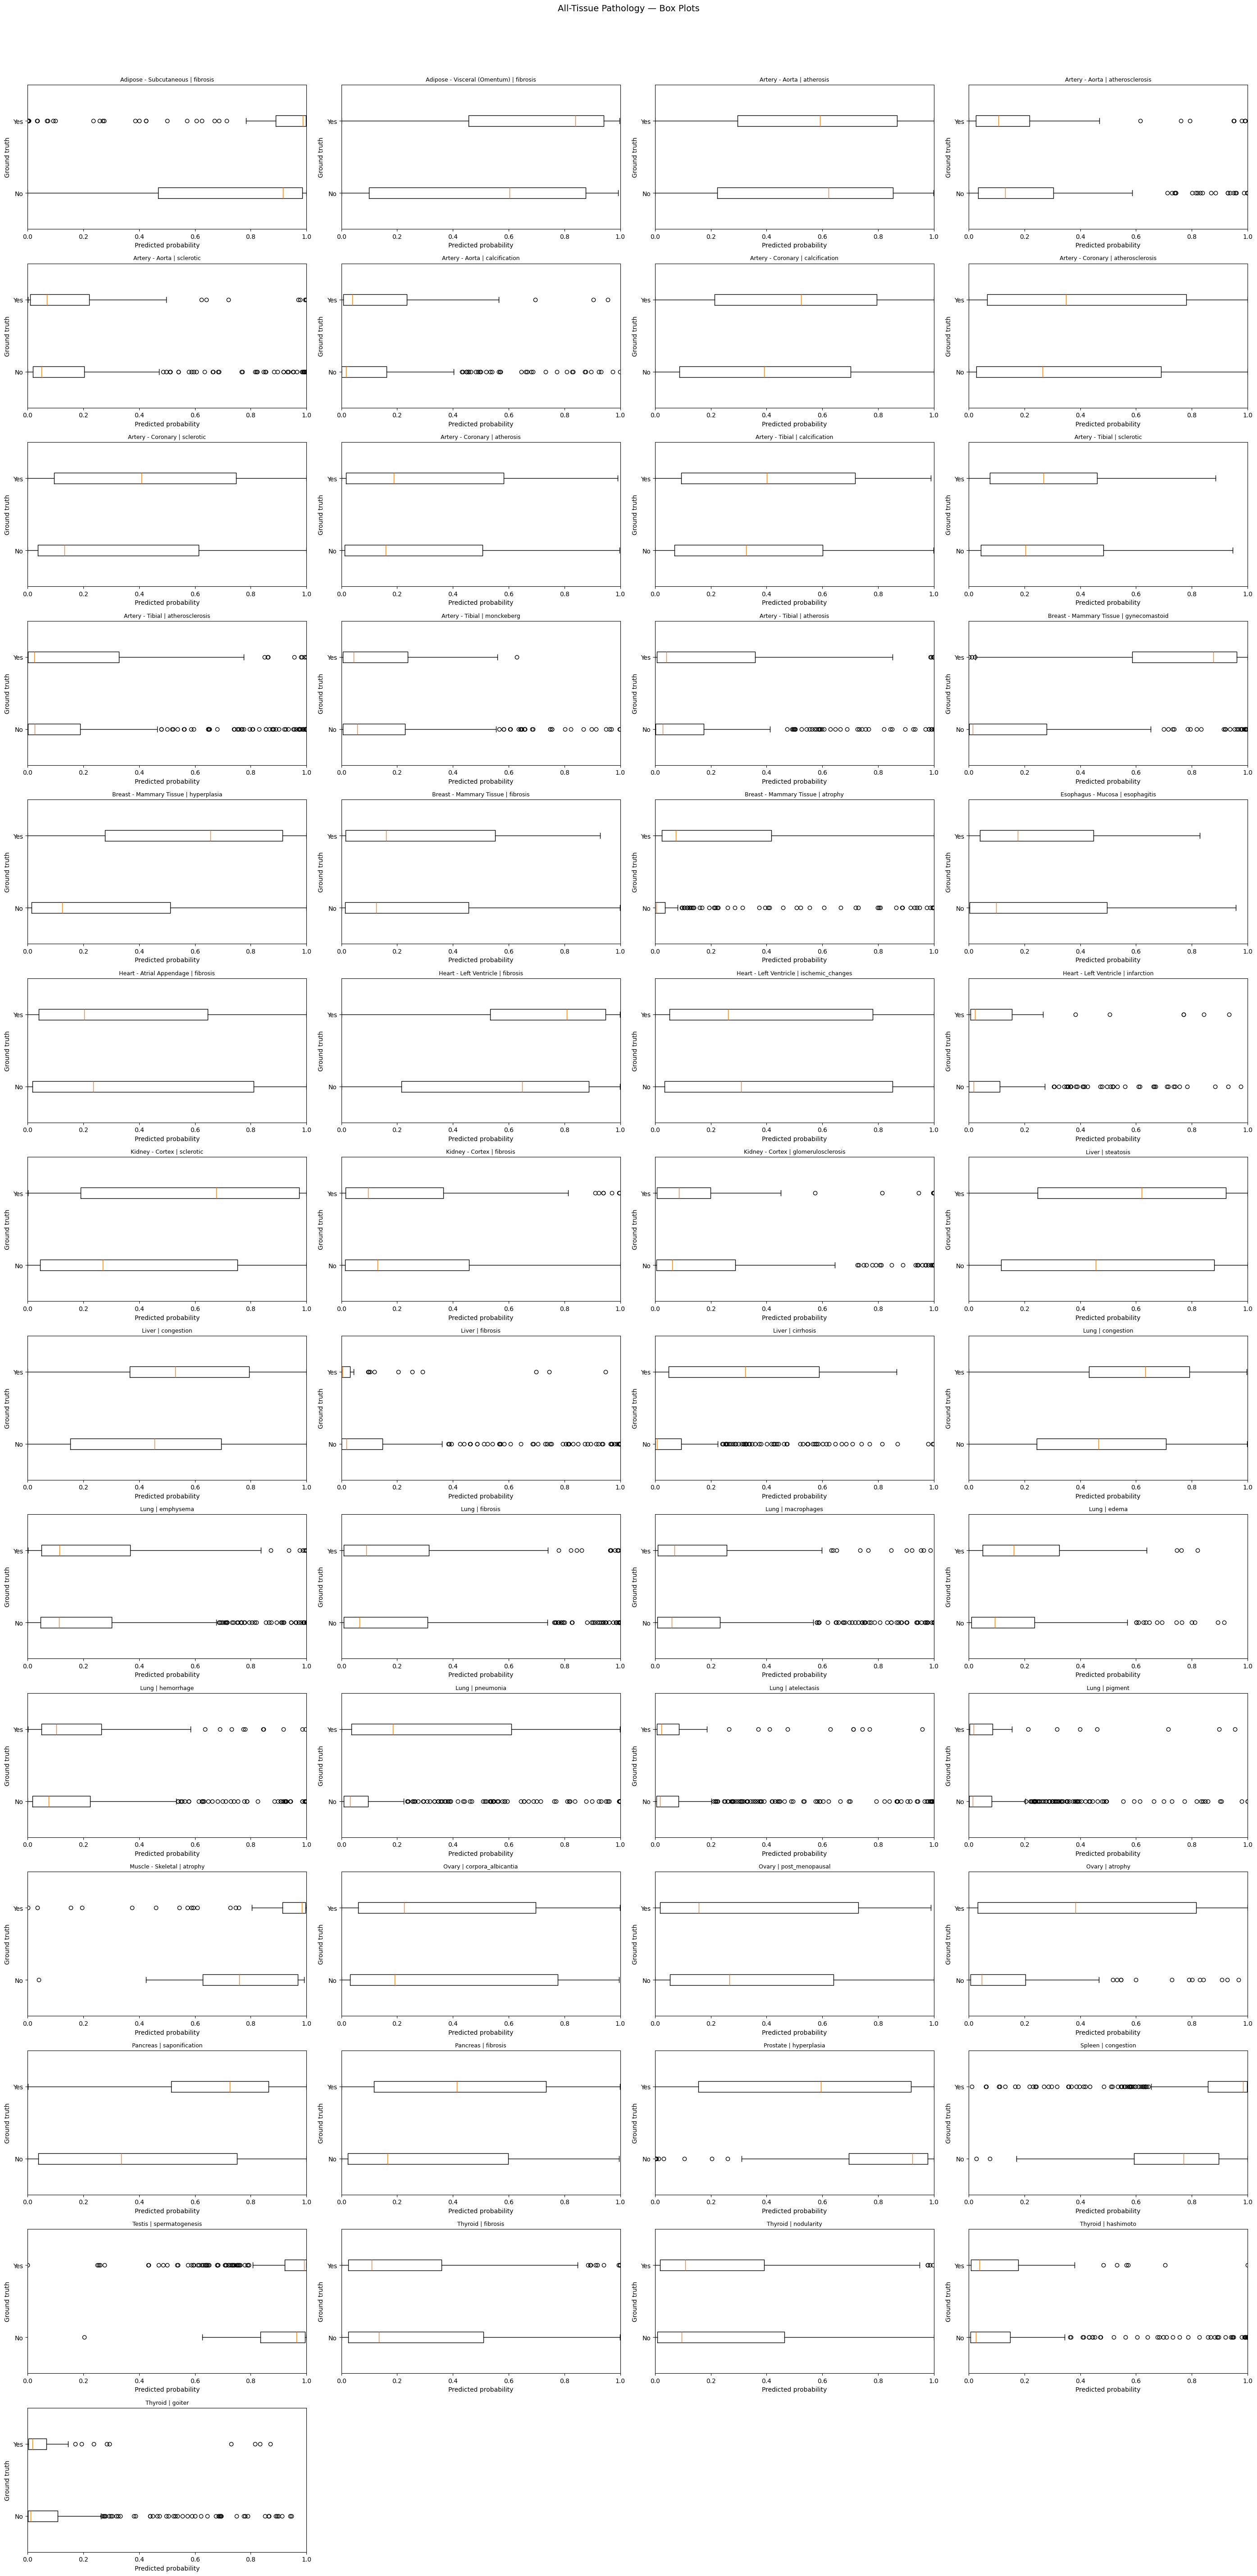

In [4]:
plot_roc_grid(all_tissue_results,
             suptitle="All-Tissue Pathology — ROC (5-fold CV)",
             save_path=Config.FIGURES_DIR / "roc_all_tissue_pathology.pdf")
plot_pr_grid(all_tissue_results,
             suptitle="All-Tissue Pathology — Precision-Recall",
             save_path=Config.FIGURES_DIR / "pr_all_tissue_pathology.pdf")
plot_cm_grid(all_tissue_results,
             suptitle="All-Tissue Pathology — Confusion Matrices",
             save_path=Config.FIGURES_DIR / "cm_all_tissue_pathology.pdf")
plot_boxplot_grid(all_tissue_results,
                  suptitle="All-Tissue Pathology — Box Plots",
                  save_path=Config.FIGURES_DIR / "boxplot_all_tissue_pathology.pdf")